## Read the input data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

from utils.utils import read_ogt_data

# SPECIFY THE DESIRED TAXONOMY SPLIT LEVEL HERE!
TAX_LEVEL = "phylum" # <--------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_gc" # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <----------- number of splits to read and process is here!!

GC_BOUNDARY = 50   # <----------------- the boundary between two binary classes

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"

In [2]:
# Read train/test/validation splits

from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_train = torch.load(data_filename_train)
    y_train = torch.load(y_filename_train)
    with open(taxa_names_filename_train, "r") as f:
        taxa_group_names_train = [line.strip() for line in f]

    # Read validation data
    data_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val = torch.load(data_filename_val)
    y_val = torch.load(y_filename_val)
    with open(taxa_names_filename_val, "r") as f:
        taxa_group_names_val = [line.strip() for line in f]
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_test = torch.load(data_filename_test)
    y_test = torch.load(y_filename_test)
    with open(taxa_names_filename_test, "r") as f:
        taxa_group_names_test = [line.strip() for line in f]
        
    X_test = (X_test > 0).int()
    X_train = (X_train > 0).int()

    if sum(y_train)/len(y_train) < 0.01 or  sum(y_test)/len(y_test) < 0.01:
        print(f"Skipping split_id = {split_id}")
        continue
    if TAX_LEVEL == "random" or TAX_LEVEL == "domain":
        taxa_group_names_train = None
        taxa_group_names_test = None
        
    if X_train is not None and y_train is not None and X_test is not None and y_test is not None and X_val is not None and y_val is not None:    
        curr_split_dict = defaultdict(str)
        curr_split_dict["X_train"] = X_train
        curr_split_dict["y_train"] = y_train
        
        curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
        curr_split_dict["X_test"] = X_test
        curr_split_dict["y_test"] = y_test
        
        curr_split_dict["X_val"] = X_val
        curr_split_dict["y_val"] = y_val
        curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
    
        all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")      

Number of added splits = 30


### 2. Noize tolerance of the original model (trained on the original train data sets)

In [43]:
import joblib
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor

TRAINED_MOD_DIR = "trained_models_train_val_test"

use_gpu = torch.cuda.is_available()
tree_method = "gpu_hist" if use_gpu else "hist"
predictor = "gpu_predictor" if use_gpu else "auto"
tree_method = "gpu_hist" if use_gpu else "hist"

# Create output directory for trained models if it doesn't exist
if not os.path.exists(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}")

In [45]:
def make_xgb():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
       # predictor=predictor,
        n_jobs=-1
    )

def make_xgb_regressor(tree_method="auto"):
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1,
        objective="reg:squarederror",  
        eval_metric="rmse"              
    )  

def make_xgb_quantile_regressor(alpha, tree_method="auto"):
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1,
        objective="reg:quantileerror",
        quantile_alpha=alpha,
    )    

In [48]:
from tqdm import tqdm

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

from utils.utils_ancestral_predict import label_ogt_range

temp_bound = GC_BOUNDARY

# Train and save models for each data split
trained_models = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"): #all_splits_dict.keys()
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]


    range_labels = label_ogt_range(y_label_train)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
    range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

    # 1. Classifier model
    gating_model_with_noise = make_xgb()
    gating_model_with_noise.fit(X_val_train, range_ids, sample_weight=sample_weights)

    # Convert to numpy
    X_train_np = X_val_train.cpu().numpy()
    y_train_np = y_label_train.cpu().numpy().flatten()
    
    # Right and left regressors
    low_mask = y_train_np < temp_bound
    high_mask = y_train_np >= temp_bound

    # Train the left and right regressors
    model_low_with_noise = make_xgb_regressor()
    model_high_with_noise = make_xgb_regressor()
    model_low_with_noise.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_high_with_noise.fit(X_train_np[high_mask], y_train_np[high_mask])

    # Lower bound regressors (e.g. 10th percentile)
    model_low_q10 = make_xgb_quantile_regressor(0.1)
    model_high_q10 = make_xgb_quantile_regressor(0.1)
    
    # Upper bound regressors (e.g. 90th percentile)
    model_low_q90 = make_xgb_quantile_regressor(0.9)
    model_high_q90 = make_xgb_quantile_regressor(0.9)
    
    model_low_q10.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_low_q90.fit(X_train_np[low_mask], y_train_np[low_mask])
    
    model_high_q10.fit(X_train_np[high_mask], y_train_np[high_mask])
    model_high_q90.fit(X_train_np[high_mask], y_train_np[high_mask])
    
    trained_models[split_id] = (gating_model_with_noise, model_low_with_noise, model_high_with_noise, model_low_q10, model_low_q90, model_high_q10, model_high_q90)

Training splits: 100%|██████████████████████████████████████████████████████████████████████| 30/30 [22:36<00:00, 45.23s/it]


In [62]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data_classif_and_regress, plot_one_accur_measure

cog_remov_add_accuracies_orig_models = eval_trained_models_on_noisy_data_classif_and_regress(trained_models, all_splits_dict, hard_fn_flag = True, test_or_val = "test")

In [63]:
# Create the output directory for plots if it doesn't exist yet
if not os.path.exists(f"{OUTPUT_DIRECTORY}/plots"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/plots")

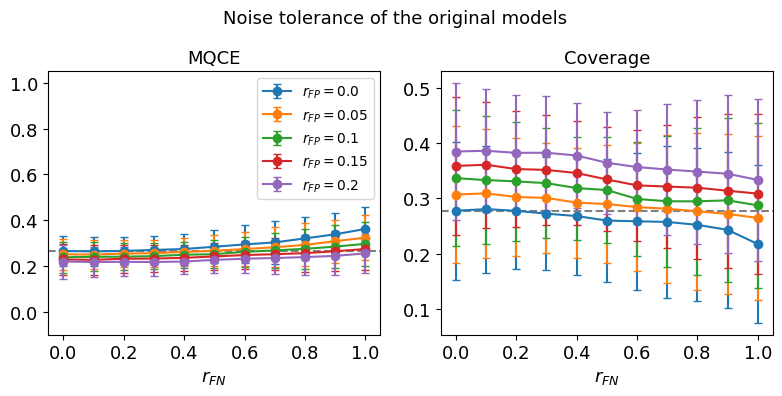

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

FONTSIZE = 13

plots = [
    ("mqce_final", "MQCE", (-0.1, 1.05)),
    ("coverage_final", "Coverage", None),
]

for ax, (metric, title, ylim) in zip(axes, plots):
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies_orig_models)

    ax.axhline(
        cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_title(title, fontsize=FONTSIZE)

    if ylim is not None:
        ax.set_ylim(*ylim)

axes[0].legend()

plt.suptitle("Noise tolerance of the original models", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models_classif_regress_calibr.svg",
    format="svg",
    bbox_inches="tight",
)

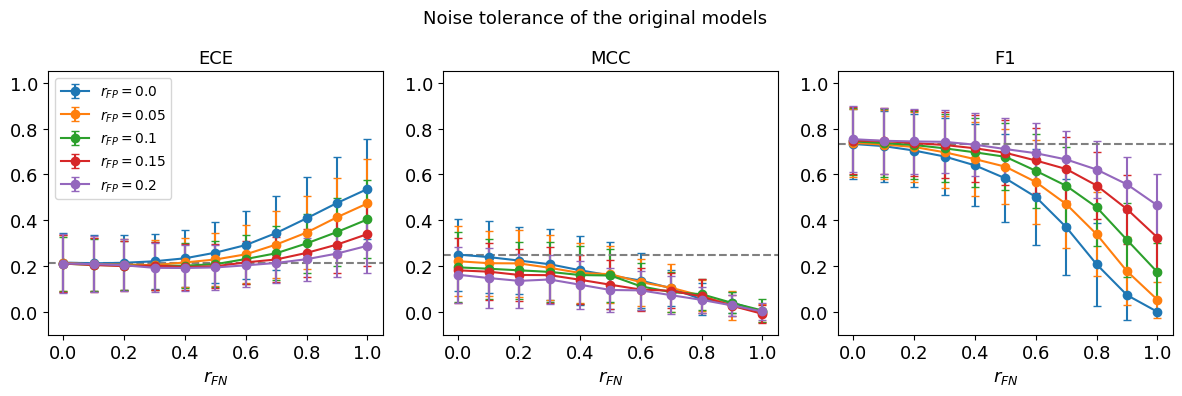

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = [
    ("ece", "ECE"),
    ("mcc", "MCC"),
    ("f1", "F1"),
]

for ax, (metric, title) in zip(axes, metrics):
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies_orig_models)

    ax.axhline(
        cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_ylim(-0.1, 1.05)
    ax.set_title(title, fontsize=FONTSIZE)

axes[0].legend()

plt.suptitle("Noise tolerance of the original models", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models_classif.pdf",
    format="pdf",
    bbox_inches="tight",
)

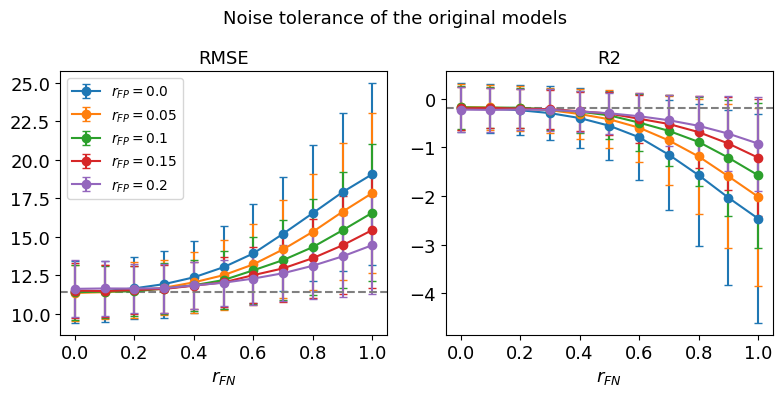

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

metrics = [
    ("rmse", "RMSE"),
    ("r2", "R2"),
]

for ax, (metric, title) in zip(axes, metrics):
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies_orig_models)

    ax.axhline(
        cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_title(title, fontsize=FONTSIZE)

axes[0].legend()

plt.suptitle("Noise tolerance of the original models", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models_regr.pdf",
    format="pdf",
    bbox_inches="tight",
)

### 3. Noise tolerance of the models trained on noisy data

Here we train the original models for each train/test split and explore their performance on the noisy test data. The noise on the test dataset is implemented as the fraction false positives and false negatives.

#### 3.1 Analyze performance of the models on the high noise range [min_fp, max_fp], [min_fn, max_fn]

Processing noise types:   0%|                                                                         | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|█████████████████████▋                                           | 1/3 [00:01<00:03,  1.89s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████▎                     | 2/3 [00:03<00:01,  1.53s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.55s/it]


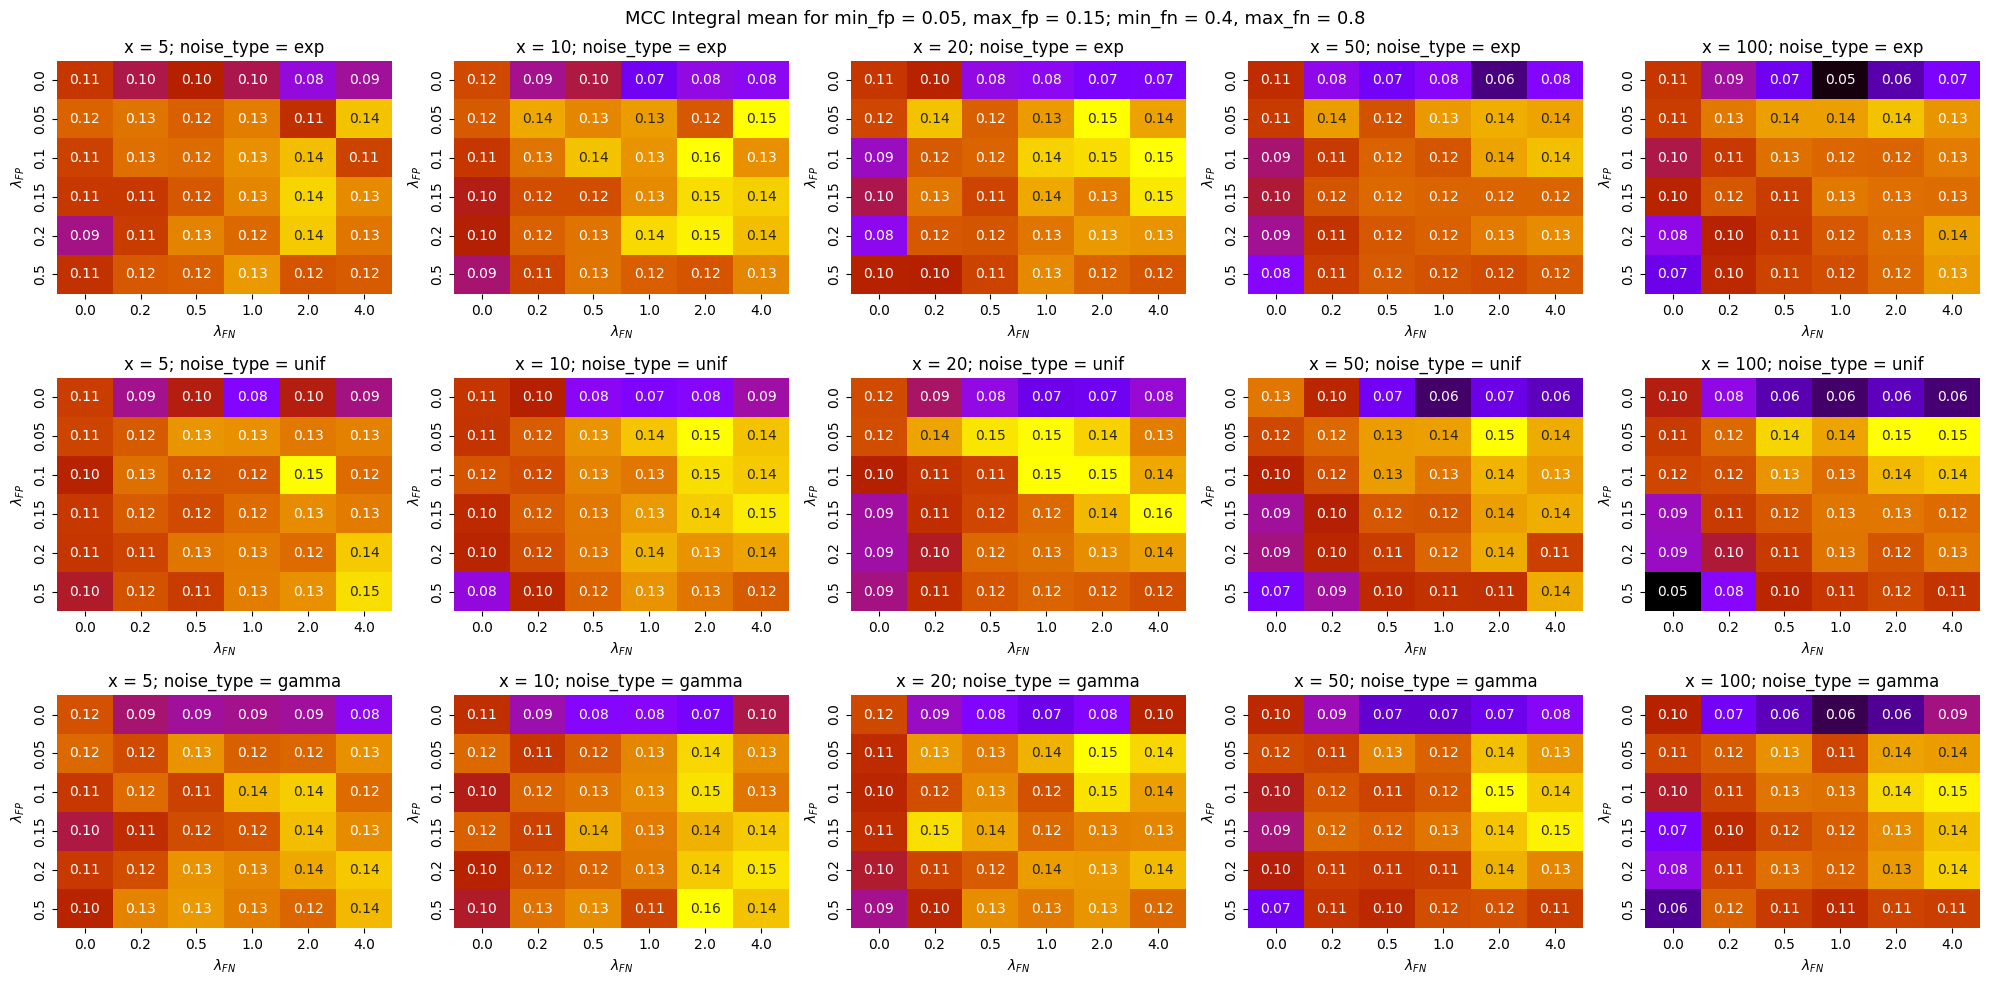

In [56]:
# Find the integrals of the MCC curves calculated for models trained on diffrent noise ranges and fisualize the result

from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data, fp_curve_areas_one_model, fp_fn_surface_integral, plot_model_groups_surf_int, eval_trained_models_on_noisy_data_classif_and_regress

FONTSIZE = 13

# Specify the noise range for the test data
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]

# Specify the min and max noise ranges for the test data (the ranges for which the integrals will be calculated)
min_fn = 0.4
max_fn = 0.8

min_fp = 0.05
max_fp = 0.15

# Specify the paraters of the models trained on noise augmented data
x_range = [5, 10, 20, 50, 100]
noise_type_range = ["exp", "unif", "gamma"]

# Calculate the integrals for each trained model and visualize the result
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_mcc_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")#eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)     
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.05, vmax=0.15, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/mcc_integral_actoss_noise.svg", format="svg", bbox_inches='tight') 

Processing noise types:   0%|                                                                         | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|█████████████████████▋                                           | 1/3 [00:01<00:02,  1.06s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████▎                     | 2/3 [00:02<00:01,  1.15s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.25s/it]


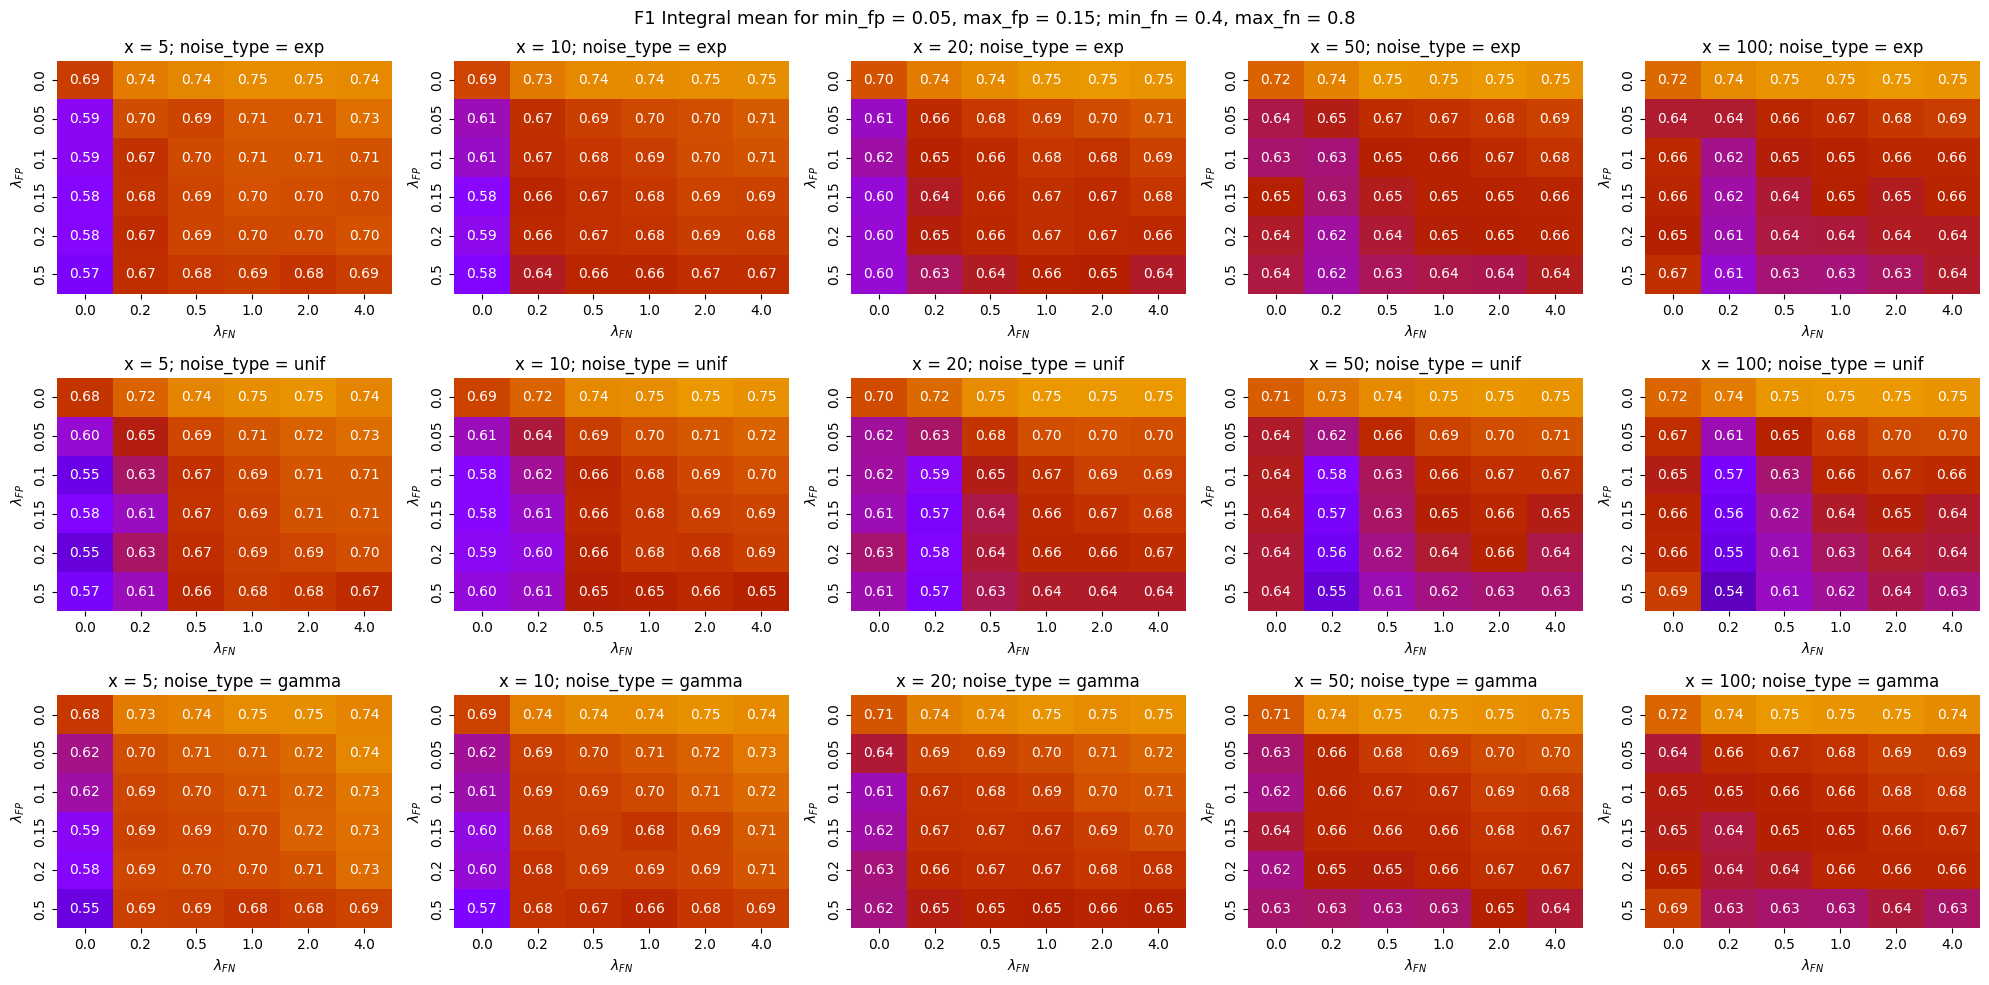

In [57]:
# Find the integrals of the F1 curves calculated for models trained on diffrent noise ranges and fisualize the result

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_f1_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")#eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'f1'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)     
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.5, vmax=0.8, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"F1 Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/f1_integral_actoss_noise.svg", format="svg", bbox_inches='tight') 

Processing noise types:   0%|                                                                         | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|█████████████████████▋                                           | 1/3 [00:01<00:02,  1.05s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████▎                     | 2/3 [00:02<00:01,  1.14s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.24s/it]


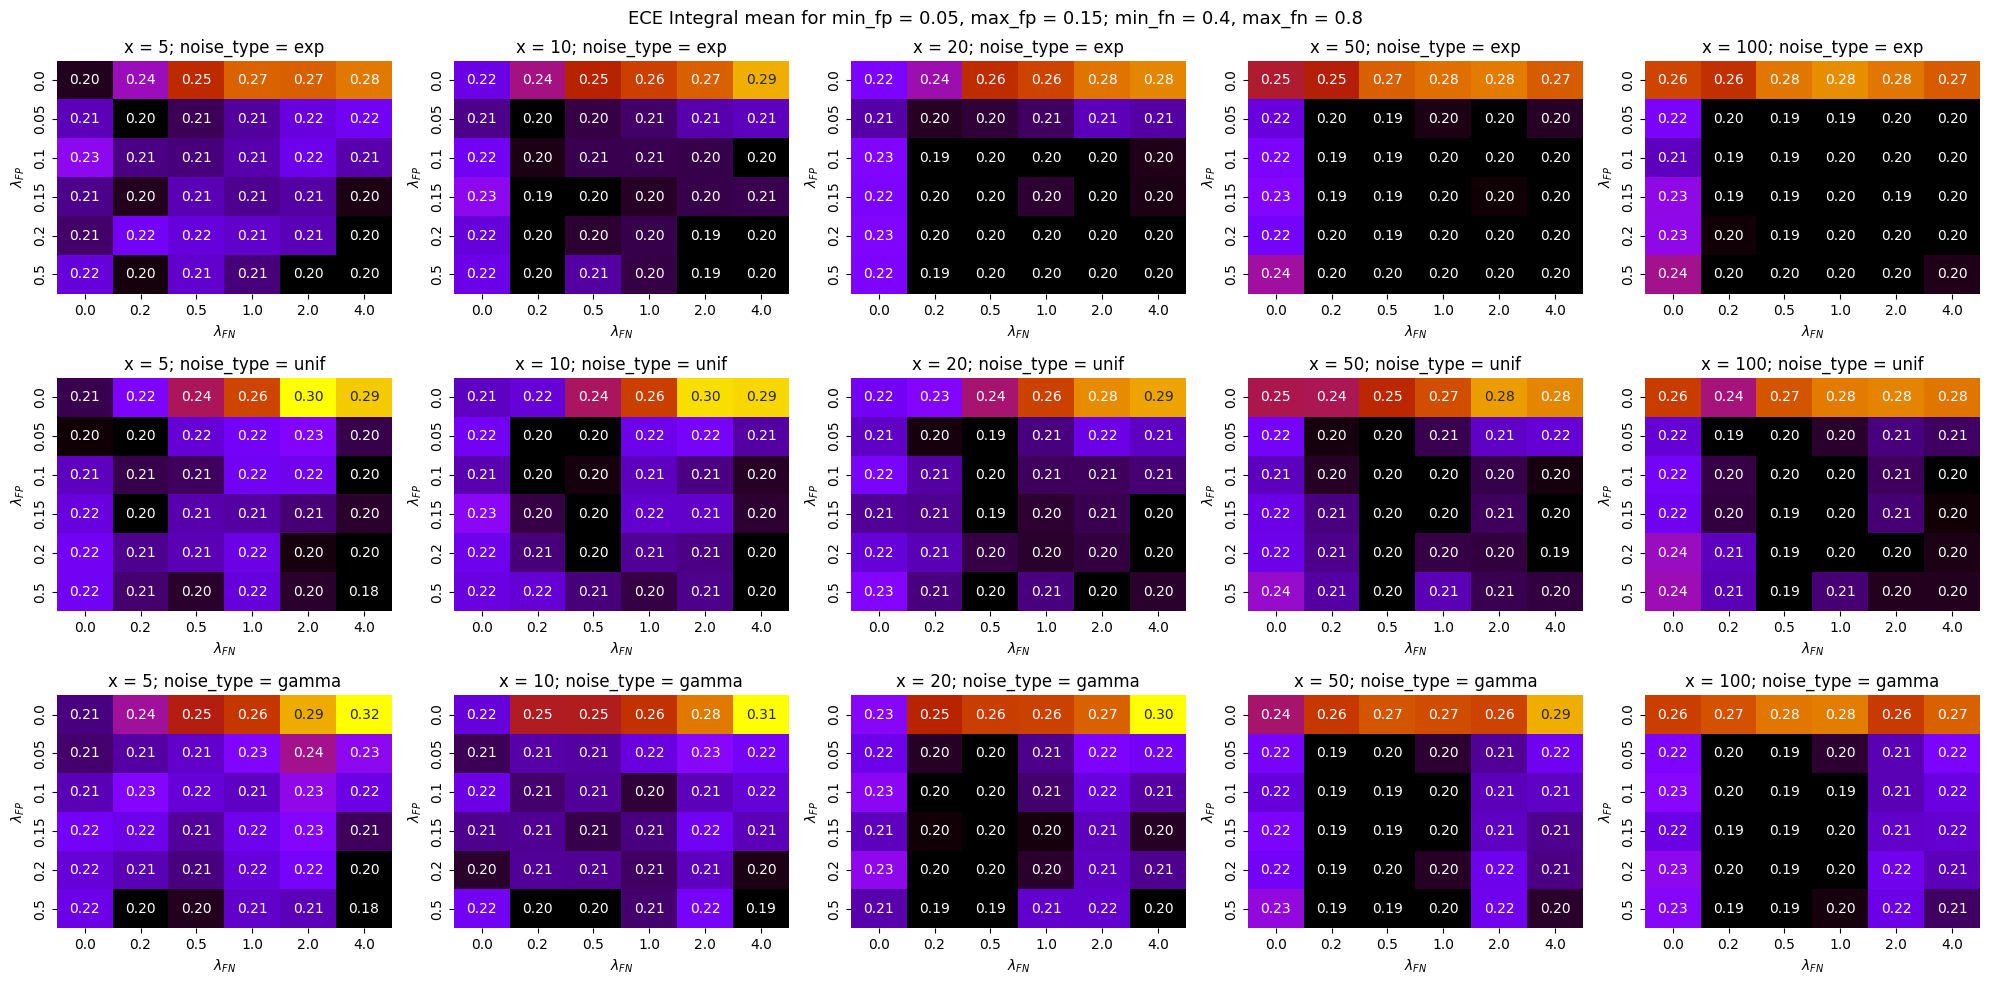

In [58]:
# Find the integrals of the ECE curves calculated for models trained on diffrent noise ranges and fisualize the result

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_ece_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(loaded_models_dict, all_splits_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")#eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'ece'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)     
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.2, vmax=0.3, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"ECE Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/ece_integral_actoss_noise.svg", format="svg", bbox_inches='tight') 

#### 3.2  Visualize the performance improvement for the chosen model

In [59]:
# Choose a model
x_noisy_samples = 20
fp_rate_mean = 0.1
fn_rate_mean = 1.0
noise_type = "unif"

filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/trained_models_train_val_test/{filename}")

In [60]:
# Re-train the chosen models, and calculate MQCE for them (the other pre-trained model don't have MQCE due to high computational cost)

from utils.utils_ancestral_predict import augment_data_with_noise

cog_remov_add_accuracies = defaultdict(dict)

temp_bound = GC_BOUNDARY

noise_robust_trained_models = {}
for split_id in tqdm(range(4), desc="Training splits"): #all_splits_dict.keys()
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    X_augmented, y_augmented = augment_data_with_noise(X_val_train, y_label_train, n_clones=x_noisy_samples, mean_fp=fp_rate_mean, mean_fn=fn_rate_mean, noise_type=noise_type)


    range_labels = label_ogt_range(y_augmented)
    le = LabelEncoder()
    range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
    label_to_int = {'low': 0, 'high': 1}
    range_ids = np.vectorize(label_to_int.get)(range_labels)

    classes = np.unique(range_ids)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
    class_weights = dict(zip(classes, weights))
    sample_weights = np.array([class_weights[c] for c in range_ids])

    sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
    range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

    # 1. Classifier model
    gating_model_with_noise = make_xgb()
    gating_model_with_noise.fit(X_augmented, range_ids, sample_weight=sample_weights)

    # Convert to numpy
    X_train_np = X_augmented.cpu().numpy()
    y_train_np = y_augmented.cpu().numpy().flatten()
    
    # Right and left regressors
    low_mask = y_train_np < temp_bound
    high_mask = y_train_np >= temp_bound

    # Train the left and right regressors
    model_low_with_noise = make_xgb_regressor()
    model_high_with_noise = make_xgb_regressor()
    model_low_with_noise.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_high_with_noise.fit(X_train_np[high_mask], y_train_np[high_mask])

    # Lower bound regressors (e.g. 10th percentile)
    model_low_q10 = make_xgb_quantile_regressor(0.1)
    model_high_q10 = make_xgb_quantile_regressor(0.1)
    
    # Upper bound regressors (e.g. 90th percentile)
    model_low_q90 = make_xgb_quantile_regressor(0.9)
    model_high_q90 = make_xgb_quantile_regressor(0.9)
    
    model_low_q10.fit(X_train_np[low_mask], y_train_np[low_mask])
    model_low_q90.fit(X_train_np[low_mask], y_train_np[low_mask])
    
    model_high_q10.fit(X_train_np[high_mask], y_train_np[high_mask])
    model_high_q90.fit(X_train_np[high_mask], y_train_np[high_mask])
    
    noise_robust_trained_models[split_id] = (gating_model_with_noise, model_low_with_noise, model_high_with_noise, model_low_q10, model_low_q90, model_high_q10, model_high_q90)

Training splits: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [41:22<00:00, 620.71s/it]


In [61]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data_classif_and_regress

cog_remov_add_accuracies = eval_trained_models_on_noisy_data_classif_and_regress(noise_robust_trained_models, all_splits_dict, hard_fn_flag = True, test_or_val = "test")

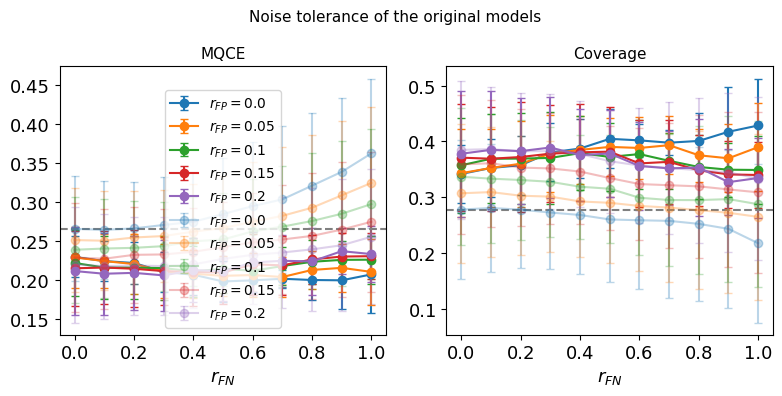

In [68]:
import matplotlib.pyplot as plt

FONTSIZE = 11

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

plots = [
    ("mqce_final", "MQCE"),
    ("coverage_final", "Coverage"),
]

for ax, (metric, title) in zip(axes, plots):
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies)
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies_orig_models, alpha=0.3)

    ax.axhline(
        cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_title(title, fontsize=FONTSIZE)

axes[0].legend()

plt.suptitle("Noise tolerance of the original models", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/"
    f"noise_toler_noisy_model_FP_{fp_rate_mean}_"
    f"FN_{fn_rate_mean}_x_{x_noisy_samples}_{metric}_regress_calibr.svg",
    format="svg",
    bbox_inches="tight",
)

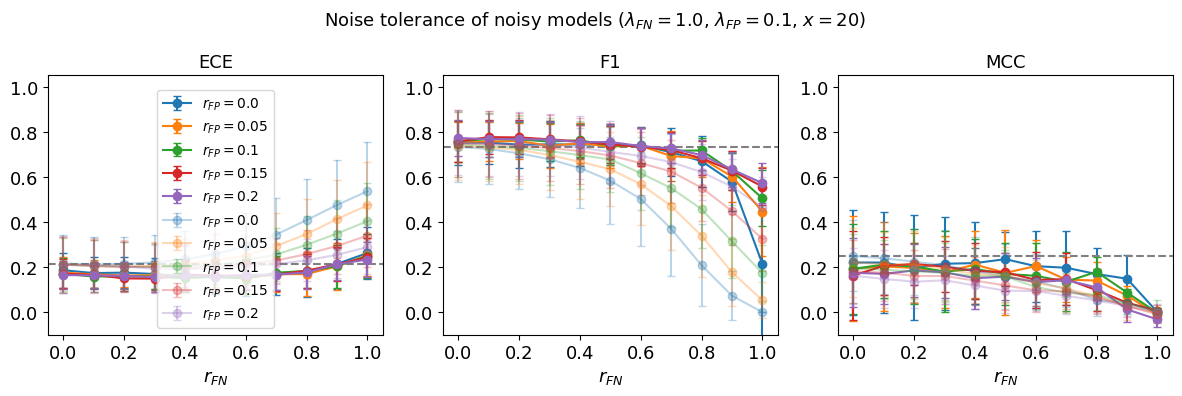

In [69]:
import matplotlib.pyplot as plt

FONTSIZE = 13

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

plots = [
    ("ece", "ECE"),
    ("f1", "F1"),
    ("mcc", "MCC"),
]

for ax, (metric, title) in zip(axes, plots):
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies)
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies_orig_models, alpha=0.3)

    ax.axhline(
        cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_ylim(-0.1, 1.05)
    ax.set_title(title, fontsize=FONTSIZE)

axes[0].legend()

plt.suptitle(
    rf"Noise tolerance of noisy models "
    rf"($\lambda_{{FN}}={fn_rate_mean}$, "
    rf"$\lambda_{{FP}}={fp_rate_mean}$, "
    rf"$x={x_noisy_samples}$)",
    fontsize=FONTSIZE,
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/"
    f"noise_toler_noisy_model_FP_{fp_rate_mean}_"
    f"FN_{fn_rate_mean}_x_{x_noisy_samples}_classif.svg",
    format="svg",
    bbox_inches="tight",
)

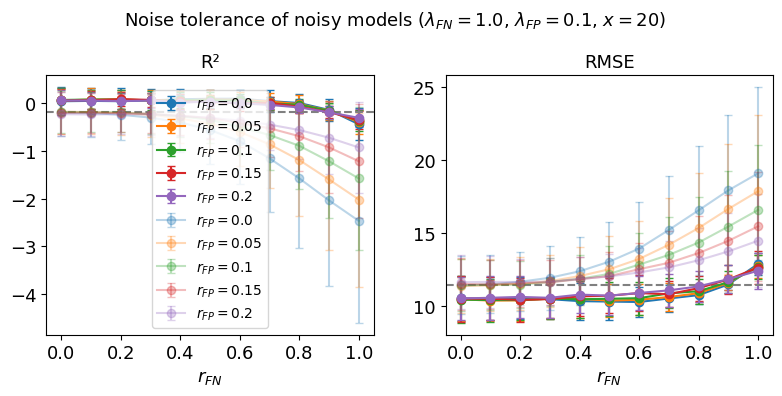

In [70]:
import matplotlib.pyplot as plt

FONTSIZE = 13

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

plots = [
    ("r2", "R²"),
    ("rmse", "RMSE"),
]

for ax, (metric, title) in zip(axes, plots):
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies)
    plot_one_accur_measure(ax, metric, cog_remov_add_accuracies_orig_models, alpha=0.3)

    ax.axhline(
        cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_title(title, fontsize=FONTSIZE)

axes[0].legend()

plt.suptitle(
    rf"Noise tolerance of noisy models "
    rf"($\lambda_{{FN}}={fn_rate_mean}$, "
    rf"$\lambda_{{FP}}={fp_rate_mean}$, "
    rf"$x={x_noisy_samples}$)",
    fontsize=FONTSIZE,
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/"
    f"noise_toler_noisy_model_FP_{fp_rate_mean}_"
    f"FN_{fn_rate_mean}_x_{x_noisy_samples}_regress.svg",
    format="svg",
    bbox_inches="tight",
)

### 5.  Ancestral phenotype prediction

In [12]:
# Read the annotated count table and get the list of COGs from there
gc_cogs = pd.read_csv("../data_gc/gc_kegg.csv", sep=",")
X_column_names = gc_cogs.columns[gc_cogs.columns.str.startswith("COG")].tolist()

In [7]:
# Read the GTDB tables for the genome taxonomy

import polars as pl

BAC_TSV = '../data_preparation/gtdb_files/bac120_metadata_r202.tsv'
ARC_TSV = '../data_preparation/gtdb_files/ar122_metadata_r202.tsv'

tax_level = "phylum"
tax_levels = {"domain": 0, "phylum": 1, "class": 2, "order": 3, "family": 4}

gtdb_df = pl.concat([pl.read_csv(BAC_TSV, separator="\t"),
    pl.read_csv(ARC_TSV, separator="\t")])
gtdb_df = gtdb_df[['accession', "gtdb_taxonomy"]]
for key in tax_levels.keys():
    tax_level = tax_levels[key]
    gtdb_df = gtdb_df.with_columns(pl.col("gtdb_taxonomy").str.split(';').list.get(tax_levels[key]).alias(key))
gtdb_df = gtdb_df.drop("gtdb_taxonomy")
#gtdb_df = gtdb_df[['accession', tax_level]]
gtdb_df = gtdb_df.to_pandas()
gtdb_df

,accession,domain,phylum,class,order,family
0,GB_GCA_000013845.2,d__Bacteria,p__Firmicutes_A,c__Clostridia,o__Clostridiales,f__Clostridiaceae
1,GB_GCA_000016465.1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Pasteurellaceae
2,GB_GCA_000024525.1,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Cytophagales,f__Spirosomaceae
3,GB_GCA_000152525.1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Pseudomonadales,f__Pseudomonadaceae
4,GB_GCA_000172955.1,d__Bacteria,p__Campylobacterota,c__Campylobacteria,o__Campylobacterales,f__Helicobacteraceae
...,...,...,...,...,...,...
258401,RS_GCF_900109065.1,d__Archaea,p__Halobacteriota,c__Halobacteria,o__Halobacteriales,f__Haloferacaceae
258402,RS_GCF_900114585.1,d__Archaea,p__Methanobacteriota,c__Methanobacteria,o__Methanobacteriales,f__Methanobacteriaceae
258403,RS_GCF_900773915.1,d__Archaea,p__Halobacteriota,c__Methanosarcinia,o__Methanosarcinales,f__Methanosarcinaceae
258404,RS_GCF_902384055.1,d__Archaea,p__Methanobacteriota,c__Methanobacteria,o__Methanobacteriales,f__Methanobacteriaceae


In [8]:
# Get the species tree leaf node names
leaves_acc_names = pd.read_csv("../ancestral_data/GenomesInfo.csv", sep=",")
columns_to_keep = ['accession', 'ShortCode']
leaves_acc_names = leaves_acc_names[columns_to_keep]
leaves_acc_names

,accession,ShortCode
0,GB_GCA_003599535.1,AABM5X1
1,GB_GCA_005223185.1,AABM5X2
2,GB_GCA_002127415.1,AABM5X3
3,GB_GCA_003598085.1,Abys1
4,GB_GCA_003223555.1,Acid1
...,...,...
1002,GB_GCA_001775395.1,Zixi1
1003,GB_GCA_002791595.1,Zixi2
1004,GB_GCA_003105265.1,Zixi3
1005,GB_GCA_002838945.1,Zixi4


In [9]:
leave_nodes_with_taxonomy = pd.merge(leaves_acc_names, gtdb_df, on="accession", how="inner")
leave_nodes_with_taxonomy

,accession,ShortCode,domain,phylum,class,order,family
0,GB_GCA_003599535.1,AABM5X1,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
1,GB_GCA_005223185.1,AABM5X2,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
2,GB_GCA_002127415.1,AABM5X3,d__Bacteria,p__AABM5-125-24,c__AABM5-125-24,o__AABM5-125-24,f__AABM5-125-24
3,GB_GCA_003598085.1,Abys1,d__Bacteria,p__Abyssubacteria,c__SURF-5,o__SURF-5,f__SURF-5
4,GB_GCA_003223555.1,Acid1,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Fen-336,f__Fen-336
...,...,...,...,...,...,...,...
992,GB_GCA_001775395.1,Zixi1,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UBA10806,f__UBA10806
993,GB_GCA_002791595.1,Zixi2,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UM-FILTER-46-8,f__UM-FILTER-46-8
994,GB_GCA_003105265.1,Zixi3,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__FEB-12
995,GB_GCA_002838945.1,Zixi4,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__PGXB01


In [10]:
# Read the tree file and pivot it into a COG count table

df = pd.read_csv('../ancestral_data/TableAncestralRoot1_aggregated_byCOG.tsv', sep='\t', dtype={'column_name': str})
df = df.T

df.columns = df.loc['COG']
df = df.drop(index='COG')
df.columns.name = None

pivot_df = df.apply(pd.to_numeric)
pivot_df.index = pivot_df.index.str.replace(r'\(\d+\)$', '', regex=True)

node_names = pivot_df.index.tolist()
pivot_df

,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0010,COG0012,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
AABM5X1,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
AABM5X2,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
AABM5X3,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Abys1,1.00,1.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Acid1,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,0.55,0.58,0.76,0.37,1.00,0.01,0.12,1.00,1.00,0.23,...,0.01,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.01,0.0
2009,0.26,0.38,0.09,0.31,0.91,0.00,0.24,0.68,0.08,1.00,...,0.02,0.0,0.00,0.0,0.02,0.0,0.0,0.0,0.09,0.0
2010,0.24,0.51,0.91,0.13,0.70,0.00,0.06,1.00,0.68,0.15,...,0.01,0.0,0.03,0.0,0.00,0.0,0.0,0.0,0.01,0.0
2011,0.08,0.07,0.14,0.08,0.29,0.00,0.05,0.88,0.23,0.13,...,0.00,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.00,0.0


In [ ]:
# Optionally: threshold the COG count values to convert them to 0/1s
threshold = 0.04
pivot_df = pivot_df.applymap(lambda x: 0 if x <= threshold else max(x, 1))
pivot_df

In [13]:
# Find COGs that are in the intersection between the COG set from the species tree and the COGs from the annotated data

cogs_from_mastertable = list(pivot_df.columns)
cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))

# Apply the intersection COGs to the species tree count table
tree_nodes_data = pivot_df[cogs_intersect]
tree_nodes_data

,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0010,COG0012,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
AABM5X1,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
AABM5X2,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
AABM5X3,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Abys1,1.00,1.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Acid1,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,0.55,0.58,0.76,0.37,1.00,0.01,0.12,1.00,1.00,0.23,...,0.01,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.01,0.0
2009,0.26,0.38,0.09,0.31,0.91,0.00,0.24,0.68,0.08,1.00,...,0.02,0.0,0.00,0.0,0.02,0.0,0.0,0.0,0.09,0.0
2010,0.24,0.51,0.91,0.13,0.70,0.00,0.06,1.00,0.68,0.15,...,0.01,0.0,0.03,0.0,0.00,0.0,0.0,0.0,0.01,0.0
2011,0.08,0.07,0.14,0.08,0.29,0.00,0.05,0.88,0.23,0.13,...,0.00,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.00,0.0


In [16]:
# Prepare model train data

ogt_cogs = pd.read_csv("../data_gc/gc_kegg.csv", sep=",")
gc_annot = pd.read_csv("../data_gc/gc_annot.csv", sep=",")
merged_tab  = pd.merge(ogt_cogs, gc_annot, on="accession", how="inner") 
merged_tab["gc_binary"] = np.where(merged_tab["gc_content"] > GC_BOUNDARY, "high", "low")

merged_tab

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,...,COG5658,COG5659,COG5660,COG5661,COG5662,COG5663,COG5664,COG5665,gc_content,gc_binary
0,GB_GCA_000023725.1,1,1,0,0,0,1,0,2,2,...,0,0,0,0,0,0,0,0,42.70,low
1,GB_GCA_000026125.1,2,2,0,2,0,1,2,3,2,...,0,0,0,0,1,0,0,0,54.30,high
2,GB_GCA_000043285.1,0,0,0,0,0,0,1,2,1,...,0,0,0,0,0,0,0,0,27.40,low
3,GB_GCA_000063505.1,1,1,0,1,1,1,1,2,1,...,0,0,0,0,0,0,0,0,60.20,high
4,GB_GCA_000063525.1,1,1,0,1,1,1,1,2,1,...,0,0,0,0,0,0,0,0,60.80,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6582,RS_GCF_946478525.1,1,1,0,1,0,1,0,3,2,...,0,0,0,0,0,0,0,0,42.30,low
6583,RS_GCF_949281285.1,0,1,0,1,1,1,1,3,1,...,0,2,0,0,0,0,0,0,61.31,high
6584,RS_GCF_951793255.1,1,1,0,1,1,1,1,3,1,...,0,0,0,0,0,0,0,0,63.65,high
6585,RS_GCF_958453765.1,1,1,0,1,1,2,1,3,1,...,0,0,0,0,0,0,0,0,47.64,low


In [17]:
# Prepare phenotype annotation vector

y_label_train_class = torch.tensor(merged_tab["gc_binary"].map({"high": 1, "low": 0}).to_numpy(), dtype=torch.long)
y_label_train_regr = torch.tensor(merged_tab["gc_content"].to_numpy(), dtype=torch.long)
numeric_df = merged_tab.iloc[:, 1:-2]
numeric_values = torch.tensor(numeric_df.values, dtype=torch.float32)
numeric_values = (numeric_values> 0).int() 

X_column_names = merged_tab.columns.tolist()[1:-1]
name_to_idx = {name: i for i, name in enumerate(X_column_names)}

# Keep only those in cogs_intersect AND present in X_column_names
cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))
keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

# Filter tensor and column names
X_val_train_filtered = numeric_values[:, keep_indices]
X_column_names_filtered = [X_column_names[i] for i in keep_indices]
X_val_train_filtered.shape

torch.Size([6587, 2848])

In [18]:
# Initialize XGBoost for training

from sklearn.pipeline import make_pipeline

In [23]:
from utils.utils_ancestral_predict import augment_data_with_noise

# Augment X train with the noise 
x_noisy_samples = 20#100
fp_rate_mean = 0.5
fn_rate_mean = 1.0
noise_type = "exp"

X_augmented, y_augmented = augment_data_with_noise(X_val_train_filtered, y_label_train_regr, x_noisy_samples, fp_rate_mean, fn_rate_mean, noise_type=noise_type, filename=None)

X_augmented.shape

torch.Size([138327, 2848])

In [25]:
# Train a model on noise augmented data

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
from utils.utils_ancestral_predict import label_ogt_range

pipe_with_noise = make_pipeline(make_xgb())

range_labels = label_ogt_range(y_augmented)
le = LabelEncoder()
range_ids = le.fit_transform(range_labels)  # Converts to 0,1,2
label_to_int = {'low': 0, 'high': 1}
range_ids = np.vectorize(label_to_int.get)(range_labels)

classes = np.unique(range_ids)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=range_ids)
class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[c] for c in range_ids])


# Convert to numpy
X_train_np = X_augmented.cpu().numpy()
y_train_np = y_augmented.cpu().numpy().flatten()

sample_weights_np = sample_weights if isinstance(sample_weights, np.ndarray) else sample_weights.cpu().numpy()
range_ids_np = range_ids if isinstance(range_ids, np.ndarray) else range_ids.cpu().numpy()

# 1. Gating model
classifier = make_xgb()
classifier.fit(X_augmented, range_ids, sample_weight=sample_weights)

# Right and left regressors
temp_bound = GC_BOUNDARY
low_mask = y_train_np < temp_bound
high_mask = y_train_np >= temp_bound

model_low = make_xgb_regressor()
model_high = make_xgb_regressor()
model_low.fit(X_train_np[low_mask], y_train_np[low_mask])
model_high.fit(X_train_np[high_mask], y_train_np[high_mask])

# Lower bound regressors (e.g. 10th percentile)
model_low_q10 = make_xgb_quantile_regressor(0.1)
model_high_q10 = make_xgb_quantile_regressor(0.1)

# Upper bound regressors (e.g. 90th percentile)
model_low_q90 = make_xgb_quantile_regressor(0.9)
model_high_q90 = make_xgb_quantile_regressor(0.9)

model_low_q10.fit(X_train_np[low_mask], y_train_np[low_mask])
model_low_q90.fit(X_train_np[low_mask], y_train_np[low_mask])

model_high_q10.fit(X_train_np[high_mask], y_train_np[high_mask])
model_high_q90.fit(X_train_np[high_mask], y_train_np[high_mask])

,objective,'reg:quantileerror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
# Convert tree genomes to a tensor
numeric_df = tree_nodes_data.select_dtypes(include=["number"])
ancestral_nodes_tensor = torch.tensor(numeric_df.to_numpy())

# Apply the trained model to the tree genomes
y_pred_ancestr_nodes_gating = classifier.predict(ancestral_nodes_tensor.cpu())

# Predict the probabilities of each class and find the maximum probability
y_proba_ancestr_nodes_gating = classifier.predict_proba(ancestral_nodes_tensor.cpu())
max_proba_gating = [max(x) for x in y_proba_ancestr_nodes_gating]

# Calculale the final prediction of the gating model
pred_low = model_low.predict(ancestral_nodes_tensor.cpu())
pred_high = model_high.predict(ancestral_nodes_tensor.cpu())
y_pred_ancestr_nodes_final = y_proba_ancestr_nodes_gating[:, 0] * pred_low + y_proba_ancestr_nodes_gating[:, 1] * pred_high

In [27]:
# Find the uncertanty related statistics

# gating probabilities
p_low = y_proba_ancestr_nodes_gating[:, 0]
p_high = y_proba_ancestr_nodes_gating[:, 1]

# mean predictions
pred_low_point  = model_low.predict(ancestral_nodes_tensor.cpu())
pred_high_point = model_high.predict(ancestral_nodes_tensor.cpu())

# quantile predictions
pred_low_q10  = model_low_q10.predict(ancestral_nodes_tensor.cpu())
pred_low_q90  = model_low_q90.predict(ancestral_nodes_tensor.cpu())
pred_high_q10 = model_high_q10.predict(ancestral_nodes_tensor.cpu())
pred_high_q90 = model_high_q90.predict(ancestral_nodes_tensor.cpu())

# final mixture quantiles
final_lower = p_low * pred_low_q10 + p_high * pred_high_q10
final_upper = p_low * pred_low_q90 + p_high * pred_high_q90

# interval width per node
interval_width = final_upper - final_lower

# combined variance per node (law of total variance)
sigma1_sq = ((pred_low_q90  - pred_low_q10)  / (2 * 1.28)) ** 2
sigma2_sq = ((pred_high_q90 - pred_high_q10) / (2 * 1.28)) ** 2
reg_unc   = p_low * sigma1_sq + p_high * sigma2_sq
gate_unc  = p_low * p_high * (pred_low_point - pred_high_point) ** 2
combined_var = reg_unc + gate_unc

In [29]:
# Generate a table with all genome names from the species tree and the model predictions

# Count for the correctly predicted extant genomes (the ones whose true annotations we know)
correct = 0
total = 0

tree_node_names_list = tree_nodes_data.index.tolist()

# Arrays for storing the values for each tree node 
annot_vs_pred_label = []
ogt_gating_arr = []
ogt_final_arr = []
error = []
final_lower_arr, final_upper_arr, interval_width_arr, combined_var_arr = [], [], [], []

merged_df = pd.merge(gc_annot, leaves_acc_names, on="accession", how="left")

# Iterate over all nodes in the species tree 
for idx, node in enumerate(tree_node_names_list):
    final_lower_arr.append(final_lower[idx])
    final_upper_arr.append(final_upper[idx])
    interval_width_arr.append(interval_width[idx])
    combined_var_arr.append(combined_var[idx])
    
    if node in list(merged_df['ShortCode']):
        ogt = merged_df.loc[merged_df["ShortCode"] == node, "gc_content"]
        ogt_gating_arr.append("high" if ogt.iloc[0]> GC_BOUNDARY else "low")
        ogt_final_arr.append(ogt.iloc[0])
        annot_vs_pred_label.append("annot")

        # Count the number or correctly predicted extant genomes
        if (ogt.iloc[0] > GC_BOUNDARY and y_pred_ancestr_nodes_gating[idx] == 1) or (ogt.iloc[0] < GC_BOUNDARY and y_pred_ancestr_nodes_gating[idx] == 0):
            correct += 1
        total +=1   
        error.append((ogt.iloc[0] - y_pred_ancestr_nodes_final[idx])**2)
    else:
        annot_vs_pred_label.append("predict")
        ogt_gating_arr.append("high" if y_pred_ancestr_nodes_gating[idx] == 1 else "low")  #{'low': 0, 'high': 1}
        ogt_final_arr.append(y_pred_ancestr_nodes_final[idx])

# Generate the final table
df_pred = pd.DataFrame({
    'NodeName': tree_node_names_list,
    'gc_gating': ogt_gating_arr,
    'gc_final': ogt_final_arr,
    'annot_or_predict':annot_vs_pred_label,
    'max_proba_gating': max_proba_gating,
    "proba_and_uncert": y_proba_ancestr_nodes_gating[:, 1],
    'final_lower':       final_lower_arr,
    'final_upper':       final_upper_arr,
    'interval_width':    interval_width_arr,
    'combined_var':      combined_var_arr,
})

print(f"Correct predict = {correct} of {total}; which is {correct/total}; RMSE = {np.sqrt(np.mean(error))}")
print(f"min pred temp = {np.min(ogt_final_arr)}; max pred temp = {np.max(ogt_final_arr)}")
df_pred

Correct predict = 57 of 80; which is 0.7125; RMSE = 8.376867236712695
min pred temp = 27.015; max pred temp = 73.85436


,NodeName,gc_gating,gc_final,annot_or_predict,max_proba_gating,proba_and_uncert,final_lower,final_upper,interval_width,combined_var
0,AABM5X1,high,47.289261,predict,0.575238,0.575238,40.785873,53.062744,12.276871,75.461037
1,AABM5X2,low,45.231308,predict,0.544601,0.455399,38.603081,50.202888,11.599808,74.697006
2,AABM5X3,low,42.565521,predict,0.609015,0.390985,36.556938,48.993484,12.436546,104.156525
3,Abys1,high,55.738926,predict,0.828919,0.828919,46.668339,59.502907,12.834568,77.882401
4,Acid1,high,64.084259,predict,0.940900,0.940900,55.867947,65.883034,10.015087,48.245201
...,...,...,...,...,...,...,...,...,...,...
2008,2008,low,44.786690,predict,0.549885,0.450115,37.897514,50.791801,12.894287,131.984406
2009,2009,low,44.448433,predict,0.594363,0.405637,36.182060,51.199181,15.017120,152.871185
2010,2010,low,43.247009,predict,0.596741,0.403259,36.339104,50.159386,13.820282,137.882965
2011,2011,low,45.183681,predict,0.540818,0.459182,36.980129,52.494652,15.514523,148.024796


In [30]:
# Print the prediction results for the root node
df_pred.loc[df_pred["NodeName"] == "2012"]

,NodeName,gc_gating,gc_final,annot_or_predict,max_proba_gating,proba_and_uncert,final_lower,final_upper,interval_width,combined_var
2012,2012,low,45.535934,predict,0.543169,0.456831,37.167755,53.264069,16.096313,150.073837


In [31]:
# Create and save a tree file with all the model prediction labels

from Bio import Phylo
from utils.utils_ancestral_predict import process_res

# Read the already existing tree file that we annotate with the model predictions below 
tree = Phylo.read("../ancestral_data/C65.tree", "newick")

# The names of important COGs for the phenotype
cog_names = ['COG0109', 'COG1612', 'COG1014', 'COG0026', 'COG1328', 'COG1592']

for clade in tree.find_clades(order="level"):
    node_name = clade.name if clade.name is not None else str(clade.confidence)
    
    # Generate the model prediction comments for the tree file
    gc_gating_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "gc_gating"])
    gc_final_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "gc_final"])
    predict_annot_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "annot_or_predict"])
    max_proba_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "max_proba_gating"])
    max_proba_comm = str(round(float(max_proba_comm), 2)) if max_proba_comm != '' else ''

    proba_and_uncert_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "proba_and_uncert"])
    proba_and_uncert_comm = str(round(float(proba_and_uncert_comm), 2)) if proba_and_uncert_comm != '' else ''

    final_lower_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "final_lower"])
    final_lower_comm = str(round(float(final_lower_comm), 2)) if final_lower_comm != '' else ''
    
    final_upper_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "final_upper"])
    final_upper_comm = str(round(float(final_upper_comm), 2)) if final_upper_comm != '' else ''
    
    interval_width_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "interval_width"])
    interval_width_comm = str(round(float(interval_width_comm), 2)) if interval_width_comm != '' else ''
    
    combined_var_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "combined_var"])
    combined_var_comm = str(round(float(combined_var_comm), 2)) if combined_var_comm != '' else ''
    
    if gc_gating_comm == "low":
        color = "#1f77b4"  # tab:red
    else:
        color = "#ED7D31"  # tab:orange

    comment_str = (
        f'&!color={color},'
        f'gc_gating={gc_gating_comm},'
        f'gc_final={gc_final_comm},'
        f'predict_annot={predict_annot_comm},'
        f'max_proba={max_proba_comm},'
        f'proba_and_uncert={proba_and_uncert_comm},'
        f'final_lower={final_lower_comm},'
        f'final_upper={final_upper_comm},'
        f'interval_width={interval_width_comm},'
        f'combined_var={combined_var_comm}'
    )
    for cog_name in cog_names:
        cog_count = int(pivot_df.loc[node_name, cog_name]) if cog_name in pivot_df.columns else 0  
        if cog_count > 1:
            cog_count = 1
        comment_str += f',{cog_name}={str(cog_count)}'

    clade.comment = comment_str

# Save the tree file with all annotations    
filename =   f"../ancestral_data/gc_C65_annotated_on_noisy_train_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}_ancRootTable_orig.tree"  
Phylo.write(tree, filename, "nexus")
filename

'../ancestral_data/gc_C65_annotated_on_noisy_train_fp_0.5_fn_1.0_noise_type_exp_x_20_ancRootTable_orig.tree'